In [34]:
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from matplotlib import colormaps
import pandas as pd

In [35]:
plt.style.use('ggplot')
plt.rcParams['text.color'] = 'black'
plt.rcParams['legend.labelcolor'] = 'black'

# Simulation

In this section, we will explore statistical simulation techniques based on historical data. The application will be to use is to simulate wind speed data based on historical data.

## Data Visualization

The data is from the Kelmarsh wind farm in the UK. The data is from the year 2016 and is sampled at 10 minute intervals, [https://zenodo.org/records/5841834#.YgpBQ_so-V7](https://zenodo.org/records/5841834#.YgpBQ_so-V7)

In [36]:
df = pd.read_parquet("wind_speed.parquet")

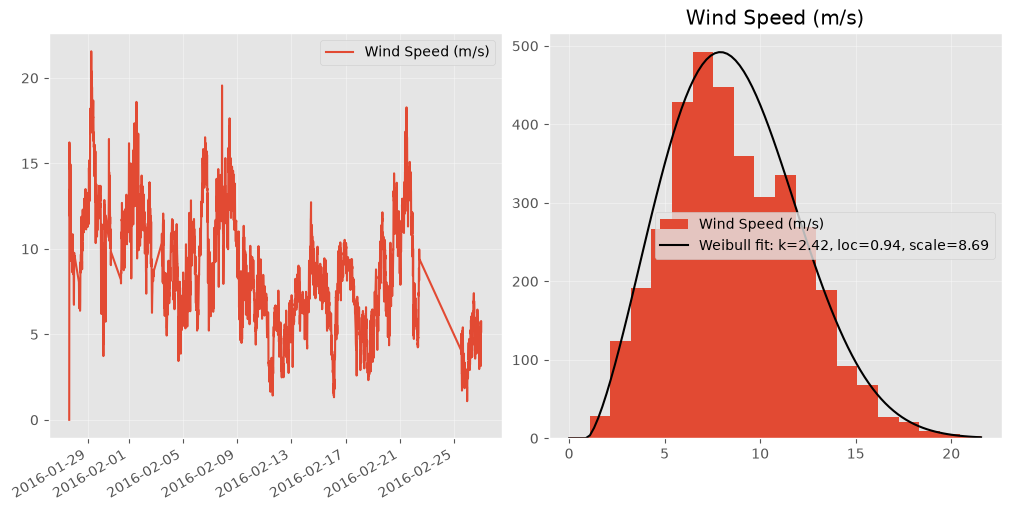

In [38]:
_, axes = plt.subplots(ncols=2, figsize=(10, 5), constrained_layout=True)
bins = 20
df.plot(ax=axes[0])
df.hist(ax=axes[1], bins=bins, legend=True)

kappa, loc, scale = stats.weibull_min.fit(df.iloc[:,0].values)
x = np.linspace(df.values.min(), df.values.max(), 100)
pdf = stats.weibull_min.pdf(x, c=kappa, loc=loc, scale=scale)

pdf *= pd.cut(df.iloc[:,0], bins=bins).value_counts().max()/np.max(pdf)
axes[1].plot(x, pdf, color='black', label=f'Weibull fit: k={kappa:.2f}, loc={loc:.2f}, scale={scale:.2f}')
axes[1].legend();

# NORmal to anything (NORTA)

In simulations, we want to generate random variables that follow a given distribution. In this section, we will focus on wind speed data, and use historical data to fit a distribution. We will then generate new wind speed data that follows the historical data distribution.
[Ref](https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/5d499a3efc8ae4dfc125756c00391ca6/$FILE/NORTA.pdf)

## Data Visualization

In [4]:
df = pd.read_parquet("wind_speed.parquet")

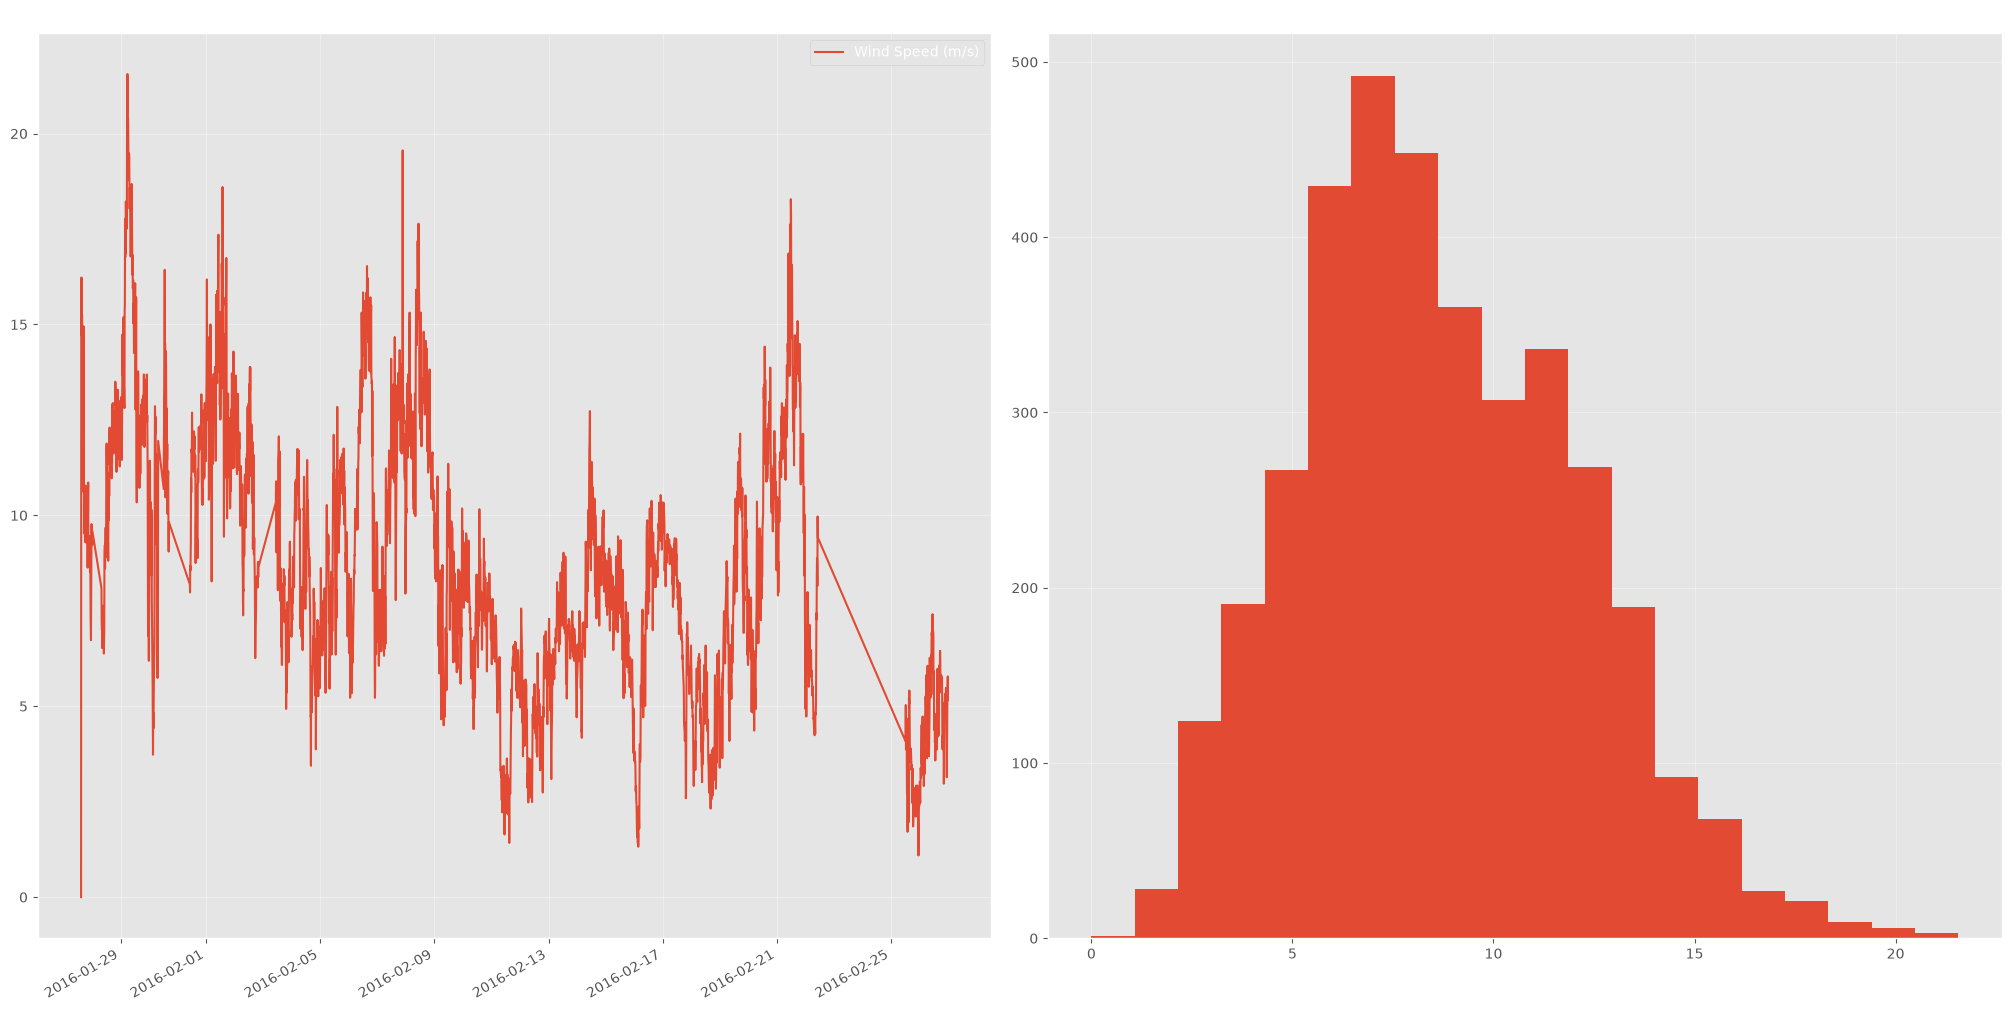

In [14]:
_, axes = plt.subplots(ncols=2, figsize=(20, 10), constrained_layout=True)

df.plot(ax=axes[0])
df.hist(ax=axes[1], bins=20);

## Fit Distribution

Wind speed data is often modeled using the Weibull distribution. This distribution is defined by

$f(x) = \frac{k}{\lambda}\left(\frac{x}{\lambda}\right)^{k-1}e^{-(x/\lambda)^k} \quad x \geq 0$

and

$f(x) = 0 \quad x < 0$


where $k$ is the shape parameter and $\lambda$ is the scale parameter. We can fit the Weibull distribution to the wind speed data using the `scipy.stats` library.

